In [42]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def gen_main_structure(n):
    """
    generates main structure
    centered on origin
    in n dimensions
    """
    rng = np.random.RandomState(1)
    return np.dot(rng.rand(n, n), rng.randn(n, 200)).T

def gen_outliers(p, n, spread=1):
    """
    outliers near a point p
    """
    return p+np.random.normal(size=(n, p.size), scale=spread)

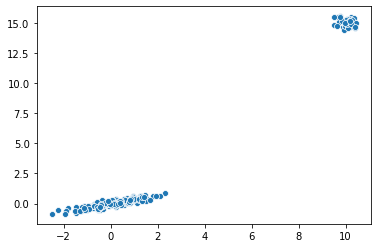

In [59]:
n = 2
p = np.array([10, 15])
outs = gen_outliers(p, 50, spread=0.25)
main = gen_main_structure(n)
combined = np.vstack((main, outs))
sns.scatterplot(x=combined[:,0], y=combined[:,1])

In [60]:
# cluster with k-means
kstar = None
merror = np.inf
for k in range(1, 15):
    m = KMeans(n_clusters=k).fit(combined)
    error = m.inertia_
    if error < merror:
        merror = error
        kstar = k
    print(f'k={k}, error={error}')
print(f'best k={kstar}')

k=1, error=13170.47841893884
k=2, error=161.41024631036544
k=3, error=66.1675259131375
k=4, error=39.09892999916977
k=5, error=26.196785501141807
k=6, error=20.820016851500604
k=7, error=17.755436042355235
k=8, error=15.323428846155144
k=9, error=13.421001913481838
k=10, error=11.62180083656469
k=11, error=10.56875211115759
k=12, error=9.503128657657701
k=13, error=8.915113723721412
k=14, error=8.418724941744433
best k=14


pca variance:
[16.83206483  0.15695849]


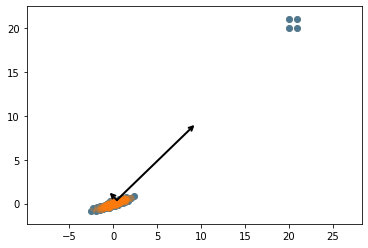

In [48]:
 
# add outliers
n = 2
X = gen_main_structure(n)
X = np.append(X,[[20,20],[21,21],[20,21],[21,20]],axis=0)
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal');

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

print('pca variance:')
print(pca.explained_variance_)

def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');
plt.show()

In [22]:
a = np.array([[1, 2, 3], [1, 2, 3], [1, 2, 3], [1, 2, 3]])
b = np.array([[1, 2, 3]])

In [25]:
a+b

array([[2, 4, 6],
       [2, 4, 6],
       [2, 4, 6],
       [2, 4, 6]])